# 04. Step 2: Category & Sentiment Classification

**Aspect-Category-Opinion-Sentiment (ACOS) Quadruple Extraction**

This notebook trains and evaluates **Step 2** of the ACOS framework:
- Automatic **Google Drive persistence** at `/content/drive/MyDrive/ACOS/` (saves `04*.ipynb`, model checkpoints, predictions, plots, metrics CSVs, and markdown reports).
- **Model Architecture (`CategorySentiClassification`):** Uses BERT with candidate aspect and opinion span representations to jointly predict aspect categories and sentiment polarities for each candidate pair.
- **Model Checkpointing:** Saves the best fine-tuned model checkpoint (`pytorch_model.bin`, `config.json`, `vocab.txt`) to session checkpoints and global `checkpoints/step2_best/` on Google Drive based on validation Micro-F1.
- **Evaluation on Pipeline Candidate Pairs:** Evaluates candidate pairs generated from Step 1 (`[domain]_test_pair_1st.tsv`) and produces complete quadruple predictions (`result.txt`), training curves, and metric CSVs.

## 1. Environment, Google Drive Setup & Module Imports
Mounts Google Drive to `/content/drive/MyDrive/ACOS/` and auto-synchronizes notebook & repository assets.

In [1]:
# 1. Mount Google Drive jika berjalan di Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Google Drive berhasil di-mount pada /content/drive")
except Exception:
    print("💻 Berjalan pada lingkungan Lokal / Colab tanpa drive mount.")

# 2. Instalasi dependensi yang dibutuhkan
!pip install -q pytorch-crf transformers huggingface_hub seaborn scikit-learn matplotlib pandas boto3 tqdm

import os
import sys
import random
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm, trange

# 3. Deteksi dinamis root direktori proyek (Prioritas Utama: Google Drive /content/drive/MyDrive/ACOS)
IS_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
HAS_DRIVE = os.path.exists("/content/drive/MyDrive")

if HAS_DRIVE:
    base_project_dir = "/content/drive/MyDrive/ACOS"
    os.makedirs(base_project_dir, exist_ok=True)
    os.makedirs(os.path.join(base_project_dir, "notebooks"), exist_ok=True)
    save_dir = os.path.join(base_project_dir, "Output")
    os.makedirs(save_dir, exist_ok=True)
    print(f"💾 Mode Google Drive Aktif: {base_project_dir}")
    print(f"📁 Output Sesi akan disimpan di: {base_project_dir}")
elif os.path.exists("Extract-Classify-ACOS"):
    base_project_dir = os.path.abspath(".")
    print(f"💾 Mode Lokal Aktif (Current Dir): {base_project_dir}")
elif os.path.exists("../Extract-Classify-ACOS"):
    base_project_dir = os.path.abspath("..")
    print(f"💾 Mode Lokal Aktif (Parent Dir): {base_project_dir}")
elif os.path.exists("ACOS/Extract-Classify-ACOS"):
    base_project_dir = os.path.abspath("ACOS")
    print(f"💾 Mode Direktori ACOS: {base_project_dir}")
elif os.path.exists("/content/ACOS/Extract-Classify-ACOS"):
    base_project_dir = "/content/ACOS"
    print(f"💾 Mode Colab Ephemeral Aktif: {base_project_dir}")
elif os.path.exists("/content/Extract-Classify-ACOS"):
    base_project_dir = "/content"
    print(f"💾 Mode Colab /content Aktif: {base_project_dir}")
else:
    base_project_dir = os.path.abspath("ACOS")
    os.makedirs(base_project_dir, exist_ok=True)
    print(f"💾 Inisialisasi folder ACOS: {base_project_dir}")

# 4. Auto-clone repositori ACOS jika folder inti belum tersedia di base_project_dir
extract_dir = os.path.join(base_project_dir, "Extract-Classify-ACOS")
if not os.path.exists(extract_dir):
    print(f"📥 Repositori belum ditemukan di {base_project_dir}. Mengkloning ACOS dari GitHub...")
    !git clone https://github.com/haisyamalawwab/ACOS.git /tmp/ACOS_clone
    !cp -r /tmp/ACOS_clone/* "{base_project_dir}/"
    !rm -rf /tmp/ACOS_clone
    print("✅ Repositori berhasil disinkronkan.")

notebooks_dir = os.path.join(base_project_dir, "notebooks")

for p in [base_project_dir, extract_dir, notebooks_dir]:
    if p not in sys.path:
        sys.path.insert(0, p)

# 5. Pastikan notebook 04*.ipynb tersimpan di /content/drive/MyDrive/ACOS
def ensure_notebook_saved_to_drive():
    if not HAS_DRIVE:
        return
    cur_nb = "04_ACOS_Step2_Category_Sentiment_Classification.ipynb"
    targets = [
        os.path.join(base_project_dir, cur_nb),
        os.path.join(base_project_dir, "notebooks", cur_nb)
    ]
    sources = [
        cur_nb,
        os.path.join("notebooks", cur_nb),
        os.path.join("/content", cur_nb),
        os.path.join("/content", "ACOS", "notebooks", cur_nb),
        os.path.join("/content", "ACOS", cur_nb),
    ]
    for src in sources:
        if os.path.exists(src):
            src_abs = os.path.abspath(src)
            for tgt in targets:
                tgt_abs = os.path.abspath(tgt)
                if src_abs != tgt_abs:
                    os.makedirs(os.path.dirname(tgt_abs), exist_ok=True)
                    try:
                        shutil.copy2(src_abs, tgt_abs)
                        print(f"💾 Salinan {cur_nb} berhasil disimpan ke: {tgt_abs}")
                    except Exception as e:
                        print(f"⚠️ Gagal menyalin ke {tgt_abs}: {e}")
            break

ensure_notebook_saved_to_drive()

import torch
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset
from modeling import CategorySentiClassification
from bert_utils.tokenization import BertTokenizer
from bert_utils.optimization import BertAdam
from run_classifier_dataset_utils import processors, output_modes, convert_examples_to_features2nd
from dataset_utils import read_pair_gold
from eval_metrics import pair_eval

# 6. Import colab_utils dengan fallback download
try:
    from colab_utils import (
        setup_timestamped_run_dir, download_bert_pretrained, analyze_and_plot_eda,
        plot_training_history, export_benchmark_tables_and_plots,
        display_quadruple_dataframe, df_to_markdown, export_step_table,
        MarkdownReport, SubtaskMetricCapture, plot_subtask_metrics,
        features_step1, features_step2, pair_examples_from_file,
        resolve_eval_pair_file, unpack_model_output,
    )
except ModuleNotFoundError:
    import urllib.request
    print("⚠️ Downloading colab_utils.py fallback directly from GitHub...")
    raw_url = "https://raw.githubusercontent.com/haisyamalawwab/ACOS/main/notebooks/colab_utils.py"
    urllib.request.urlretrieve(raw_url, "colab_utils.py")
    from colab_utils import (
        setup_timestamped_run_dir, download_bert_pretrained, analyze_and_plot_eda,
        plot_training_history, export_benchmark_tables_and_plots,
        display_quadruple_dataframe, df_to_markdown, export_step_table,
        MarkdownReport, SubtaskMetricCapture, plot_subtask_metrics,
        features_step1, features_step2, pair_examples_from_file,
        resolve_eval_pair_file, unpack_model_output,
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ Active PyTorch Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU Model: {torch.cuda.get_device_name(0)}")
print(f"📂 Base project directory: {base_project_dir}")
print(f"📁 Extract & Model directory: {extract_dir}")

⚡ Active PyTorch Device: cuda
   GPU Model: Tesla T4
📂 Base project directory: /content/ACOS
📁 Extract & Model directory: /content/ACOS/Extract-Classify-ACOS


## 2. Configuration & Hyperparameters

In [2]:
DOMAIN = "rest16"              # 'rest16' or 'laptop'
TASK_NAME = "categorysenti"
MODEL_TYPE = "categorysenti"
DO_TRAIN = True                # Set to False to skip training and evaluate saved checkpoint
DO_EVAL = True
MAX_SEQ_LENGTH = 128
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 16
LEARNING_RATE = 5e-5
NUM_TRAIN_EPOCHS = 15          # Default is 30, 15 is great for fast Colab training
WARMUP_PROPORTION = 0.1
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Pretrained BERT Directory (Cari di Google Drive / Lokal)
bert_candidates = [
    os.path.join(base_project_dir, "bert_base_uncased"),
    os.path.join(base_project_dir, "Output", "bert_base_uncased"),
    "/content/drive/MyDrive/ACOS/bert_base_uncased",
    "/content/drive/MyDrive/ACOS/Output/bert_base_uncased",
]
bert_model_dir = os.path.join(base_project_dir, "bert_base_uncased")
for bc in bert_candidates:
    if os.path.exists(os.path.join(bc, "pytorch_model.bin")):
        bert_model_dir = bc
        break
download_bert_pretrained(target_dir=bert_model_dir)

data_dir = extract_dir
results_base_candidates = [
    os.path.join(base_project_dir, "results"),
    os.path.join(base_project_dir, "Output", "results"),
    "/content/drive/MyDrive/ACOS/results",
    "/content/drive/MyDrive/ACOS/Output/results"
]
results_base = os.path.join(base_project_dir, "results")
for rb in results_base_candidates:
    if os.path.exists(rb):
        results_base = rb
        break

session_dirs = setup_timestamped_run_dir(base_dir=results_base, domain=DOMAIN)
step2_checkpoint_dir = session_dirs["step2_checkpoint"]
global_step2_ckpt = os.path.join(base_project_dir, "checkpoints", "step2_best")
os.makedirs(global_step2_ckpt, exist_ok=True)

print(f"📁 Step 2 Checkpoint sesi akan disimpan di: {step2_checkpoint_dir}")
print(f"📁 Step 2 Checkpoint global akan dicadangkan ke: {global_step2_ckpt}")
plots_dir = session_dirs["plots"]
csv_dir = session_dirs["csv"]
md_dir = session_dirs["md"]
logs_dir = session_dirs["logs"]

rep = MarkdownReport(
    f"04 - Step 2: Klasifikasi Category & Sentiment [{DOMAIN.upper()}]",
    md_dir,
    filename="04_step2_klasifikasi.md",
    meta={
        "domain": DOMAIN, "epochs": NUM_TRAIN_EPOCHS,
        "batch_train": TRAIN_BATCH_SIZE, "lr": LEARNING_RATE,
        "max_seq_length": MAX_SEQ_LENGTH, "device": str(device),
        "session_dir": session_dirs["root"],
    },
)

df_cfg = pd.DataFrame([
    {"Parameter": "domain", "Nilai": DOMAIN},
    {"Parameter": "num_train_epochs", "Nilai": NUM_TRAIN_EPOCHS},
    {"Parameter": "train_batch_size", "Nilai": TRAIN_BATCH_SIZE},
    {"Parameter": "eval_batch_size", "Nilai": EVAL_BATCH_SIZE},
    {"Parameter": "learning_rate", "Nilai": LEARNING_RATE},
    {"Parameter": "max_seq_length", "Nilai": MAX_SEQ_LENGTH},
    {"Parameter": "device", "Nilai": str(device)},
])
rep.section("1. Konfigurasi")
export_step_table(df_cfg, name="step2_00_konfigurasi", csv_dir=csv_dir, md_dir=md_dir,
                  title=f"Konfigurasi Step 2 ({DOMAIN.upper()})")
rep.table(df_cfg, caption="Hyperparameter yang dipakai")

📥 Downloading config.json to /content/ACOS/bert_base_uncased/config.json ...
📥 Downloading pytorch_model.bin to /content/ACOS/bert_base_uncased/pytorch_model.bin ...
📥 Downloading vocab.txt to /content/ACOS/bert_base_uncased/vocab.txt ...
📁 Initialized timestamped session directory: /content/ACOS/results/rest16_02092026_135007
📁 Step 2 Checkpoint will be saved to: /content/ACOS/results/rest16_02092026_135007/checkpoints/step2_best
=== Konfigurasi Step 2 (REST16) (7 baris) ===


,Parameter,Nilai
0,domain,rest16
1,num_train_epochs,15
2,train_batch_size,16
3,eval_batch_size,16
4,learning_rate,0.00005
5,max_seq_length,128
6,device,cuda


[tabel] CSV: /content/ACOS/results/rest16_02092026_135007/csv/step2_00_konfigurasi.csv | MD: /content/ACOS/results/rest16_02092026_135007/md/step2_00_konfigurasi.md


## 3. Data Loading & Feature Processing

In [3]:
tokenizer = BertTokenizer.from_pretrained(bert_model_dir, do_lower_case=True)
processor = processors[TASK_NAME]()
label_list = processor.get_labels(DOMAIN)
num_labels = len(label_list[0])

print(f"Jumlah kelas gabungan CATEGORY#SENTIMENT: {num_labels}")

# Tabel daftar kelas (bukan sekadar print panjang)
df_kelas = pd.DataFrame({
    "Index": range(len(label_list[0])),
    "Label": label_list[0],
})
df_kelas["Category"] = df_kelas["Label"].str.rsplit("#", n=1).str[0]
df_kelas["Sentiment"] = df_kelas["Label"].str.rsplit("#", n=1).str[1]
rep.section("2. Ruang label")
export_step_table(df_kelas, name="step2_01_daftar_kelas", csv_dir=csv_dir, md_dir=md_dir,
                  title=f"Daftar Kelas CATEGORY#SENTIMENT ({DOMAIN.upper()}) - {num_labels} kelas",
                  notes="Kelas dibentuk dari perkalian kategori x 3 sentimen (0=negative, 1=neutral, 2=positive).",
                  max_rows_md=30)
rep.table(df_kelas.head(20), caption=f"20 dari {num_labels} kelas")

# Pilih sumber evaluasi: pasangan prediksi step 1 kalau ada, jika tidak pasangan gold.
tokenized_dir = os.path.join(data_dir, "tokenized_data")
eval_pair_file, pakai_1st = resolve_eval_pair_file(tokenized_dir, DOMAIN, prefer_1st=True)

# CategorySentiProcessor tidak punya metode untuk memilih file bebas, jadi
# example dibangun langsung dari file terpilih memakai _read_tsv/_create_examples.
eval_examples = pair_examples_from_file(processor, eval_pair_file, set_type="test")

# features_step2 membungkus convert_examples_to_features2nd(examples, label_list,
# max_seq_length, tokenizer, output_mode).
eval_features = features_step2(eval_examples, label_list, MAX_SEQ_LENGTH, tokenizer,
                               output_modes[TASK_NAME])

all_input_ids = torch.tensor([f.aspect_input_ids for f in eval_features], dtype=torch.long)
all_input_mask = torch.tensor([f.aspect_input_mask for f in eval_features], dtype=torch.long)
all_segment_ids = torch.tensor([f.aspect_segment_ids for f in eval_features], dtype=torch.long)
all_candidate_aspect = torch.tensor([f.candidate_aspect for f in eval_features], dtype=torch.long)
all_candidate_opinion = torch.tensor([f.candidate_opinion for f in eval_features], dtype=torch.long)
all_label_id = torch.tensor([f.label_id for f in eval_features], dtype=torch.float)
all_tokens_len = torch.tensor([f.tokens_len for f in eval_features], dtype=torch.long)

eval_data = TensorDataset(all_tokens_len, all_input_ids, all_input_mask, all_segment_ids,
                          all_candidate_aspect, all_candidate_opinion, all_label_id)
eval_dataloader = DataLoader(eval_data, sampler=SequentialSampler(eval_data),
                            batch_size=EVAL_BATCH_SIZE)

# Gold selalu dari file pair gold, karena itu acuan penilaian.
class ArgsProxy:
    def __init__(self):
        self.bert_model = bert_model_dir
        self.do_lower_case = True

proxy_args = ArgsProxy()
test_pair_gold_file = os.path.join(tokenized_dir, f"{DOMAIN}_test_pair.tsv")
with open(test_pair_gold_file, "r", encoding="utf-8") as f:
    eval_gold = read_pair_gold(f.readlines(), proxy_args)

print(f"Kandidat evaluasi: {len(eval_examples)} | Gold pair: {len(eval_gold[0])}")

df_sumber = pd.DataFrame([{
    "File_Kandidat_Evaluasi": os.path.basename(eval_pair_file),
    "Sumber_Kandidat": "prediksi step 1" if pakai_1st else "gold (bukan pipeline penuh)",
    "Jumlah_Kandidat": len(eval_examples),
    "File_Gold": os.path.basename(test_pair_gold_file),
    "Jumlah_Gold_Pair": len(eval_gold[0]),
}])
rep.section("3. Sumber data evaluasi")
export_step_table(df_sumber, name="step2_02_sumber_evaluasi", csv_dir=csv_dir, md_dir=md_dir,
                  title=f"Sumber Data Evaluasi Step 2 ({DOMAIN.upper()})",
                  notes=("Skor pipeline penuh hanya valid bila kandidat berasal dari prediksi step 1. "
                         "Bila memakai gold pair, angka yang muncul mengukur step 2 secara terisolasi."))
rep.table(df_sumber, caption="Sumber evaluasi")

# Distribusi label pada data evaluasi
label_freq = all_label_id.sum(dim=0).numpy()
df_lbl = pd.DataFrame({"Label": label_list[0], "Frekuensi_Gold": label_freq.astype(int)})
df_lbl = df_lbl[df_lbl["Frekuensi_Gold"] > 0].sort_values("Frekuensi_Gold", ascending=False).reset_index(drop=True)
export_step_table(df_lbl, name="step2_03_distribusi_label_eval", csv_dir=csv_dir, md_dir=md_dir,
                  title=f"Label CATEGORY#SENTIMENT Aktif pada Data Evaluasi ({DOMAIN.upper()})",
                  notes=f"{len(df_lbl)} dari {num_labels} kelas benar-benar muncul pada data evaluasi.",
                  max_rows_md=25)
rep.table(df_lbl.head(15), caption="15 label tersering")


Jumlah kelas gabungan CATEGORY#SENTIMENT: 39
=== Daftar Kelas CATEGORY#SENTIMENT (REST16) - 39 kelas (39 baris) ===


,Index,Label,Category,Sentiment
0,0,RESTAURANT#GENERAL#0,RESTAURANT#GENERAL,0
1,1,RESTAURANT#GENERAL#1,RESTAURANT#GENERAL,1
2,2,RESTAURANT#GENERAL#2,RESTAURANT#GENERAL,2
3,3,SERVICE#GENERAL#0,SERVICE#GENERAL,0
4,4,SERVICE#GENERAL#1,SERVICE#GENERAL,1
5,5,SERVICE#GENERAL#2,SERVICE#GENERAL,2
6,6,FOOD#GENERAL#0,FOOD#GENERAL,0
7,7,FOOD#GENERAL#1,FOOD#GENERAL,1
8,8,FOOD#GENERAL#2,FOOD#GENERAL,2
9,9,FOOD#QUALITY#0,FOOD#QUALITY,0


[tabel] CSV: /content/ACOS/results/rest16_02092026_135007/csv/step2_01_daftar_kelas.csv | MD: /content/ACOS/results/rest16_02092026_135007/md/step2_01_daftar_kelas.md
[data] Evaluasi memakai pasangan prediksi step 1: /content/ACOS/Extract-Classify-ACOS/tokenized_data/rest16_test_pair_1st.tsv
Kandidat evaluasi: 1346 | Gold pair: 895
=== Sumber Data Evaluasi Step 2 (REST16) (1 baris) ===


,File_Kandidat_Evaluasi,Sumber_Kandidat,Jumlah_Kandidat,File_Gold,Jumlah_Gold_Pair
0,rest16_test_pair_1st.tsv,prediksi step 1,1346,rest16_test_pair.tsv,895


[tabel] CSV: /content/ACOS/results/rest16_02092026_135007/csv/step2_02_sumber_evaluasi.csv | MD: /content/ACOS/results/rest16_02092026_135007/md/step2_02_sumber_evaluasi.md
=== Label CATEGORY#SENTIMENT Aktif pada Data Evaluasi (REST16) (0 baris) ===


,Label,Frekuensi_Gold


[tabel] CSV: /content/ACOS/results/rest16_02092026_135007/csv/step2_03_distribusi_label_eval.csv | MD: /content/ACOS/results/rest16_02092026_135007/md/step2_03_distribusi_label_eval.md


## 4. Model Initialization: `CategorySentiClassification`

In [4]:
model = CategorySentiClassification.from_pretrained(bert_model_dir, num_labels=num_labels)
model.to(device)
print(f"✅ Initialized CategorySentiClassification model ({sum(p.numel() for p in model.parameters()):,} parameters).")

✅ Initialized CategorySentiClassification model (109,542,183 parameters).


## 5. Training Loop with Model Checkpointing
Fine-tune the model on Ground Truth training pairs and persist the best checkpoint to `checkpoints/step2_best/`.

In [5]:
if DO_TRAIN:
    train_examples = processor.get_train_examples(data_dir, DOMAIN)
    train_features = features_step2(train_examples, label_list, MAX_SEQ_LENGTH, tokenizer,
                                    output_modes[TASK_NAME])

    tr_input_ids = torch.tensor([f.aspect_input_ids for f in train_features], dtype=torch.long)
    tr_input_mask = torch.tensor([f.aspect_input_mask for f in train_features], dtype=torch.long)
    tr_segment_ids = torch.tensor([f.aspect_segment_ids for f in train_features], dtype=torch.long)
    tr_candidate_aspect = torch.tensor([f.candidate_aspect for f in train_features], dtype=torch.long)
    tr_candidate_opinion = torch.tensor([f.candidate_opinion for f in train_features], dtype=torch.long)
    tr_label_id = torch.tensor([f.label_id for f in train_features], dtype=torch.float)
    tr_tokens_len = torch.tensor([f.tokens_len for f in train_features], dtype=torch.long)

    train_data = TensorDataset(tr_tokens_len, tr_input_ids, tr_input_mask, tr_segment_ids,
                               tr_candidate_aspect, tr_candidate_opinion, tr_label_id)
    train_dataloader = DataLoader(train_data, sampler=RandomSampler(train_data),
                                 batch_size=TRAIN_BATCH_SIZE)

    num_train_optimization_steps = len(train_dataloader) * NUM_TRAIN_EPOCHS

    param_optimizer = list(model.named_parameters())
    no_decay = ["bias", "LayerNorm.bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {"params": [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)], "weight_decay": 0.01},
        {"params": [p for n, p in param_optimizer if any(nd in n for nd in no_decay)], "weight_decay": 0.0},
    ]
    optimizer = BertAdam(optimizer_grouped_parameters, lr=LEARNING_RATE,
                         warmup=WARMUP_PROPORTION, t_total=num_train_optimization_steps)

    print(f"Mulai training step 2: {NUM_TRAIN_EPOCHS} epoch, {len(train_dataloader)} step/epoch")

    class ArgsHelper:
        def __init__(self):
            self.output_dir = logs_dir
            self.max_seq_length = MAX_SEQ_LENGTH

    eval_args = ArgsHelper()

    import logging
    logger = logging.getLogger("Step2")

    best_val_f1 = 0.0
    training_history = []
    step_loss_log = []

    for epoch in range(1, NUM_TRAIN_EPOCHS + 1):
        model.train()
        total_loss = 0.0
        for step, batch in enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch}/{NUM_TRAIN_EPOCHS}")):
            batch = tuple(t.to(device) for t in batch)
            _len, _ids, _mask, _seg_ids, _cand_a, _cand_o, _lbls = batch

            # CategorySentiClassification mengembalikan ([loss], [logits]).
            out = model(
                tokenizer, epoch,
                aspect_input_ids=_ids,
                aspect_token_type_ids=_seg_ids,
                aspect_attention_mask=_mask,
                candidate_aspect=_cand_a,
                candidate_opinion=_cand_o,
                label_id=_lbls,
            )
            loss, _ = unpack_model_output(out)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            total_loss += loss.item()
            step_loss_log.append({"epoch": epoch, "step": step + 1, "loss": loss.item()})

        avg_loss = total_loss / len(train_dataloader)

        model.eval()
        val_res = pair_eval(epoch, eval_args, logger, tokenizer, model, eval_dataloader,
                            eval_gold, label_list, device, TASK_NAME, eval_type="test")

        val_p = val_res.get("precision", 0.0)
        val_r = val_res.get("recall", 0.0)
        val_f1 = val_res.get("micro-F1", 0.0)

        print(f"Epoch {epoch:02d} | loss {avg_loss:.4f} | P {val_p*100:.2f}% | "
              f"R {val_r*100:.2f}% | micro-F1 {val_f1*100:.2f}%")

        training_history.append({
            "epoch": epoch, "loss": avg_loss,
            "precision": val_p, "recall": val_r, "micro-F1": val_f1,
        })

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            print(f"  -> micro-F1 terbaik baru ({best_val_f1*100:.2f}%), menyimpan checkpoint")
            torch.save(model.state_dict(), os.path.join(step2_checkpoint_dir, "pytorch_model.bin"))
            model.config.to_json_file(os.path.join(step2_checkpoint_dir, "config.json"))
            tokenizer.save_vocabulary(step2_checkpoint_dir)
            # Salinan cadangan ke direktori global checkpoint di Google Drive
            try:
                torch.save(model.state_dict(), os.path.join(global_step2_ckpt, "pytorch_model.bin"))
                model.config.to_json_file(os.path.join(global_step2_ckpt, "config.json"))
                tokenizer.save_vocabulary(global_step2_ckpt)
            except Exception:
                pass
            with open(os.path.join(step2_checkpoint_dir, "checkpoint_metadata.json"), "w") as mf:
                json.dump({
                    "epoch": epoch, "best_micro_f1": best_val_f1,
                    "precision": val_p, "recall": val_r,
                    "domain": DOMAIN, "task": "Step2_Category_Sentiment_Classification",
                }, mf, indent=2)

    plot_history_path = os.path.join(plots_dir, "04_step2_training_loss_f1_curve.png")
    csv_history_path = os.path.join(csv_dir, "step2_training_history.csv")
    plot_training_history(training_history, task_name="Step 2 (Category-Sentiment)",
                          output_plot_path=plot_history_path, output_csv_path=csv_history_path)

    df_hist = pd.DataFrame(training_history)
    df_hist_pct = df_hist.copy()
    for c in ["precision", "recall", "micro-F1"]:
        df_hist_pct[c] = (df_hist_pct[c] * 100).round(2)

    rep.section("4. Riwayat training per epoch")
    export_step_table(df_hist_pct, name="step2_04_riwayat_epoch", csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Riwayat Training Step 2 per Epoch ({DOMAIN.upper()})",
                      notes="Metrik dihitung pada level quadruple lengkap lewat pair_eval.",
                      max_rows_md=NUM_TRAIN_EPOCHS)
    rep.table(df_hist_pct, max_rows=NUM_TRAIN_EPOCHS, caption="Metrik per epoch")

    df_steps = pd.DataFrame(step_loss_log)
    export_step_table(df_steps.groupby("epoch")["loss"].describe().reset_index(),
                      name="step2_05_statistik_loss_per_epoch", csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Statistik Loss per Epoch ({DOMAIN.upper()})",
                      max_rows_md=NUM_TRAIN_EPOCHS)
    df_steps.to_csv(os.path.join(csv_dir, "step2_loss_per_step.csv"), index=False, encoding="utf-8")

    best_row = df_hist_pct.loc[df_hist_pct["micro-F1"].idxmax()]
    rep.section("5. Epoch terbaik").kv({
        "epoch": int(best_row["epoch"]),
        "loss": f"{best_row['loss']:.4f}",
        "precision": f"{best_row['precision']:.2f}%",
        "recall": f"{best_row['recall']:.2f}%",
        "micro-F1": f"{best_row['micro-F1']:.2f}%",
        "checkpoint": step2_checkpoint_dir,
    })
    print(f"Epoch terbaik: {int(best_row['epoch'])} (micro-F1 {best_row['micro-F1']:.2f}%)")
else:
    print("DO_TRAIN=False, training dilewati. Lanjut ke pemuatan checkpoint.")
    training_history = []


Mulai training step 2: 15 epoch, 152 step/epoch


Epoch 1/15:   0%|          | 0/152 [00:00<?, ?it/s]/content/ACOS/Extract-Classify-ACOS/bert_utils/optimization.py:275: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:1853.)
  next_m.mul_(beta1).add_(1 - beta1, grad)
Epoch 1/15: 100%|██████████| 152/152 [00:36<00:00,  4.14it/s]


Quad num: 0
tp: 0.0. fp: 0.0. fn: 895.0.
tp: 0.0. fp: 0.0. fn: 490.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 142.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 98.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 102.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 715.0.
4 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 399.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 123.0.
1 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 85.0.
2 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 95.0.
3 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 623.0.
4 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 497.0.
0 :  {'precision': 0, 'recall': 0.0, 'micro-F1': 0}
tp: 0.0. fp: 0.0. fn: 144.0.
1 :  {'precision': 0, 'recall': 0.0, 'micr

Epoch 2/15: 100%|██████████| 152/152 [00:34<00:00,  4.38it/s]


Quad num: 907
tp: 352.0. fp: 555.0. fn: 543.0.
tp: 278.0. fp: 44.0. fn: 212.0.
0 :  {'precision': 0.8633540372670807, 'recall': 0.5673469387755102, 'micro-F1': 0.6847290640394088}
tp: 39.0. fp: 18.0. fn: 103.0.
1 :  {'precision': 0.6842105263157895, 'recall': 0.2746478873239437, 'micro-F1': 0.39195979899497496}
tp: 46.0. fp: 10.0. fn: 52.0.
2 :  {'precision': 0.8214285714285714, 'recall': 0.46938775510204084, 'micro-F1': 0.5974025974025974}
tp: 52.0. fp: 10.0. fn: 50.0.
3 :  {'precision': 0.8387096774193549, 'recall': 0.5098039215686274, 'micro-F1': 0.6341463414634145}
tp: 370.0. fp: 76.0. fn: 345.0.
4 :  {'precision': 0.8295964125560538, 'recall': 0.5174825174825175, 'micro-F1': 0.6373815676141257}
tp: 278.0. fp: 45.0. fn: 121.0.
0 :  {'precision': 0.8606811145510835, 'recall': 0.6967418546365914, 'micro-F1': 0.7700831024930748}
tp: 47.0. fp: 9.0. fn: 76.0.
1 :  {'precision': 0.8392857142857143, 'recall': 0.3821138211382114, 'micro-F1': 0.5251396648044693}
tp: 46.0. fp: 13.0. fn: 39.0

...

Quad num: 1123
tp: 486.0. fp: 637.0. fn: 409.0.
tp: 377.0. fp: 54.0. fn: 113.0.
0 :  {'precision': 0.8747099767981439, 'recall': 0.7693877551020408, 'micro-F1': 0.8186753528773072}
tp: 90.0. fp: 24.0. fn: 52.0.
1 :  {'precision': 0.7894736842105263, 'recall': 0.6338028169014085, 'micro-F1': 0.7031250000000001}
tp: 66.0. fp: 8.0. fn: 32.0.
2 :  {'precision': 0.8918918918918919, 'recall': 0.673469387755102, 'micro-F1': 0.7674418604651163}
tp: 60.0. fp: 14.0. fn: 42.0.
3 :  {'precision': 0.8108108108108109, 'recall': 0.5882352941176471, 'micro-F1': 0.6818181818181819}
tp: 526.0. fp: 96.0. fn: 189.0.
4 :  {'precision': 0.8456591639871383, 'recall': 0.7356643356643356, 'micro-F1': 0.786836200448766}
tp: 335.0. fp: 33.0. fn: 64.0.
0 :  {'precision': 0.9103260869565217, 'recall': 0.8395989974937343, 'micro-F1': 0.8735332464146024}
tp: 90.0. fp: 10.0. fn: 33.0.
1 :  {'precision': 0.9, 'recall': 0.7317073170731707, 'micro-F1': 0.8071748878923767}
tp: 55.0. fp: 14.0. fn: 30.0.
2 :  {'precision':

,epoch,loss,precision,recall,micro-F1
0,1,0.179146,0.00,0.00,0.00
1,2,0.081772,38.81,39.33,39.07
2,3,0.052783,42.80,46.15,44.41
3,4,0.035669,41.97,43.80,42.86
4,5,0.024021,42.70,51.28,46.60
5,6,0.016258,42.47,50.39,46.09
6,7,0.011772,43.11,52.74,47.44
7,8,0.008684,42.40,52.96,47.09
8,9,0.007000,43.46,53.85,48.10
9,10,0.005742,43.14,54.08,47.99


[tabel] CSV: /content/ACOS/results/rest16_02092026_135007/csv/step2_04_riwayat_epoch.csv | MD: /content/ACOS/results/rest16_02092026_135007/md/step2_04_riwayat_epoch.md
=== Statistik Loss per Epoch (REST16) (15 baris) ===


,epoch,count,mean,std,min,25%,50%,75%,max
0,1,152.0,0.179146,0.156711,0.075385,0.103103,0.113020,0.158269,0.699599
1,2,152.0,0.081772,0.014010,0.045221,0.071009,0.081451,0.090524,0.125159
2,3,152.0,0.052783,0.011300,0.027782,0.044950,0.052634,0.059363,0.090093
3,4,152.0,0.035669,0.010180,0.013300,0.028689,0.034798,0.042487,0.062675
4,5,152.0,0.024021,0.008252,0.008174,0.018477,0.023668,0.028566,0.047029
5,6,152.0,0.016258,0.006244,0.003778,0.011727,0.015514,0.019844,0.041769
6,7,152.0,0.011772,0.005218,0.003998,0.007998,0.010782,0.014767,0.033680
7,8,152.0,0.008684,0.003995,0.002262,0.005719,0.007807,0.011072,0.020289
8,9,152.0,0.007000,0.003030,0.002370,0.004476,0.006512,0.008881,0.016684
9,10,152.0,0.005742,0.002591,0.002320,0.003897,0.005195,0.006967,0.017550


[tabel] CSV: /content/ACOS/results/rest16_02092026_135007/csv/step2_05_statistik_loss_per_epoch.csv | MD: /content/ACOS/results/rest16_02092026_135007/md/step2_05_statistik_loss_per_epoch.md
Epoch terbaik: 12 (micro-F1 48.24%)


## 6. Standalone Checkpoint Loading & Full Quadruple Evaluation
Load the saved checkpoint from `checkpoints/step2_best/` and compute final metrics across all 15 subtasks.

Memuat checkpoint step 2 terbaik dari: /content/ACOS/results/rest16_02092026_135007/checkpoints/step2_best


INFO:Step2_Final:***** category results *****
INFO:Step2_Final:  micro-F1 = 78.95%
INFO:Step2_Final:  precision = 85.00%
INFO:Step2_Final:  recall = 73.71%
INFO:Step2_Final:-----------------------------------


Quad num: 1120
tp: 486.0. fp: 634.0. fn: 409.0.
tp: 376.0. fp: 53.0. fn: 114.0.
0 :  {'precision': 0.8764568764568764, 'recall': 0.7673469387755102, 'micro-F1': 0.8182807399347116}
tp: 91.0. fp: 23.0. fn: 51.0.
1 :  {'precision': 0.7982456140350878, 'recall': 0.6408450704225352, 'micro-F1': 0.7109375000000001}
tp: 67.0. fp: 8.0. fn: 31.0.
2 :  {'precision': 0.8933333333333333, 'recall': 0.6836734693877551, 'micro-F1': 0.7745664739884393}
tp: 59.0. fp: 12.0. fn: 43.0.
3 :  {'precision': 0.8309859154929577, 'recall': 0.5784313725490197, 'micro-F1': 0.6820809248554914}
tp: 527.0. fp: 93.0. fn: 188.0.
4 :  {'precision': 0.85, 'recall': 0.737062937062937, 'micro-F1': 0.7895131086142322}
tp: 335.0. fp: 33.0. fn: 64.0.
0 :  {'precision': 0.9103260869565217, 'recall': 0.8395989974937343, 'micro-F1': 0.8735332464146024}
tp: 90.0. fp: 10.0. fn: 33.0.
1 :  {'precision': 0.9, 'recall': 0.7317073170731707, 'micro-F1': 0.8071748878923767}
tp: 55.0. fp: 15.0. fn: 30.0.
2 :  {'precision': 0.7857142857

INFO:Step2_Final:***** sentiment results *****
INFO:Step2_Final:  micro-F1 = 82.51%
INFO:Step2_Final:  precision = 87.57%
INFO:Step2_Final:  recall = 78.01%
INFO:Step2_Final:-----------------------------------
INFO:Step2_Final:***** category sentiment results *****
INFO:Step2_Final:  micro-F1 = 70.11%
INFO:Step2_Final:  precision = 75.40%
INFO:Step2_Final:  recall = 65.52%
INFO:Step2_Final:-----------------------------------
INFO:Step2_Final:***** aspect results *****
INFO:Step2_Final:  micro-F1 = 78.31%
INFO:Step2_Final:  precision = 82.22%
INFO:Step2_Final:  recall = 74.75%
INFO:Step2_Final:-----------------------------------
INFO:Step2_Final:***** category aspect results *****
INFO:Step2_Final:  micro-F1 = 67.24%
INFO:Step2_Final:  precision = 68.91%
INFO:Step2_Final:  recall = 65.66%
INFO:Step2_Final:-----------------------------------
INFO:Step2_Final:***** sentiment aspect results *****
INFO:Step2_Final:  micro-F1 = 69.18%
INFO:Step2_Final:  precision = 72.36%
INFO:Step2_Final:  

tp: 350.0. fp: 88.0. fn: 147.0.
0 :  {'precision': 0.7990867579908676, 'recall': 0.704225352112676, 'micro-F1': 0.7486631016042781}
tp: 82.0. fp: 33.0. fn: 62.0.
1 :  {'precision': 0.7130434782608696, 'recall': 0.5694444444444444, 'micro-F1': 0.6332046332046332}
tp: 54.0. fp: 21.0. fn: 47.0.
2 :  {'precision': 0.72, 'recall': 0.5346534653465347, 'micro-F1': 0.6136363636363636}
tp: 51.0. fp: 20.0. fn: 52.0.
3 :  {'precision': 0.7183098591549296, 'recall': 0.49514563106796117, 'micro-F1': 0.5862068965517241}
tp: 475.0. fp: 155.0. fn: 250.0.
4 :  {'precision': 0.753968253968254, 'recall': 0.6551724137931034, 'micro-F1': 0.7011070110701108}
tp: 433.0. fp: 98.0. fn: 147.0.
0 :  {'precision': 0.815442561205273, 'recall': 0.746551724137931, 'micro-F1': 0.7794779477947794}
tp: 114.0. fp: 13.0. fn: 39.0.
1 :  {'precision': 0.8976377952755905, 'recall': 0.7450980392156863, 'micro-F1': 0.8142857142857142}
tp: 84.0. fp: 26.0. fn: 55.0.
2 :  {'precision': 0.7636363636363637, 'recall': 0.60431654676

,Metrik,Nilai,Persen
0,precision,0.433929,43.39
1,recall,0.543017,54.30
2,micro-F1,0.482382,48.24


[tabel] CSV: /content/ACOS/results/rest16_02092026_135007/csv/step2_06_hasil_quadruple_final.csv | MD: /content/ACOS/results/rest16_02092026_135007/md/step2_06_hasil_quadruple_final.md

Hasil akhir quadruple pada test set:
  precision: 43.39%
  recall: 54.30%
  micro-F1: 48.24%
=== Metrik 15 Sub-Task Hasil Evaluasi Nyata (REST16) (15 baris) ===


,Subtask,N_Elements,TP,FP,FN,Precision,Recall,Micro_F1
0,sentiment,1,NaN,NaN,NaN,87.57,78.01,82.51
1,category,1,NaN,NaN,NaN,85.00,73.71,78.95
2,opinion,1,NaN,NaN,NaN,81.75,76.20,78.88
3,aspect,1,NaN,NaN,NaN,82.22,74.75,78.31
4,sentiment opinion,2,NaN,NaN,NaN,73.89,69.70,71.74
5,category sentiment,2,NaN,NaN,NaN,75.40,65.52,70.11
6,sentiment aspect,2,NaN,NaN,NaN,72.36,66.26,69.18
7,category aspect,2,NaN,NaN,NaN,68.91,65.66,67.24
8,category opinion,2,NaN,NaN,NaN,64.54,66.02,65.27
9,aspect opinion,2,NaN,NaN,NaN,52.50,64.47,57.87


[tabel] CSV: /content/ACOS/results/rest16_02092026_135007/csv/step2_07_metrik_15_subtask.csv | MD: /content/ACOS/results/rest16_02092026_135007/md/step2_07_metrik_15_subtask.md


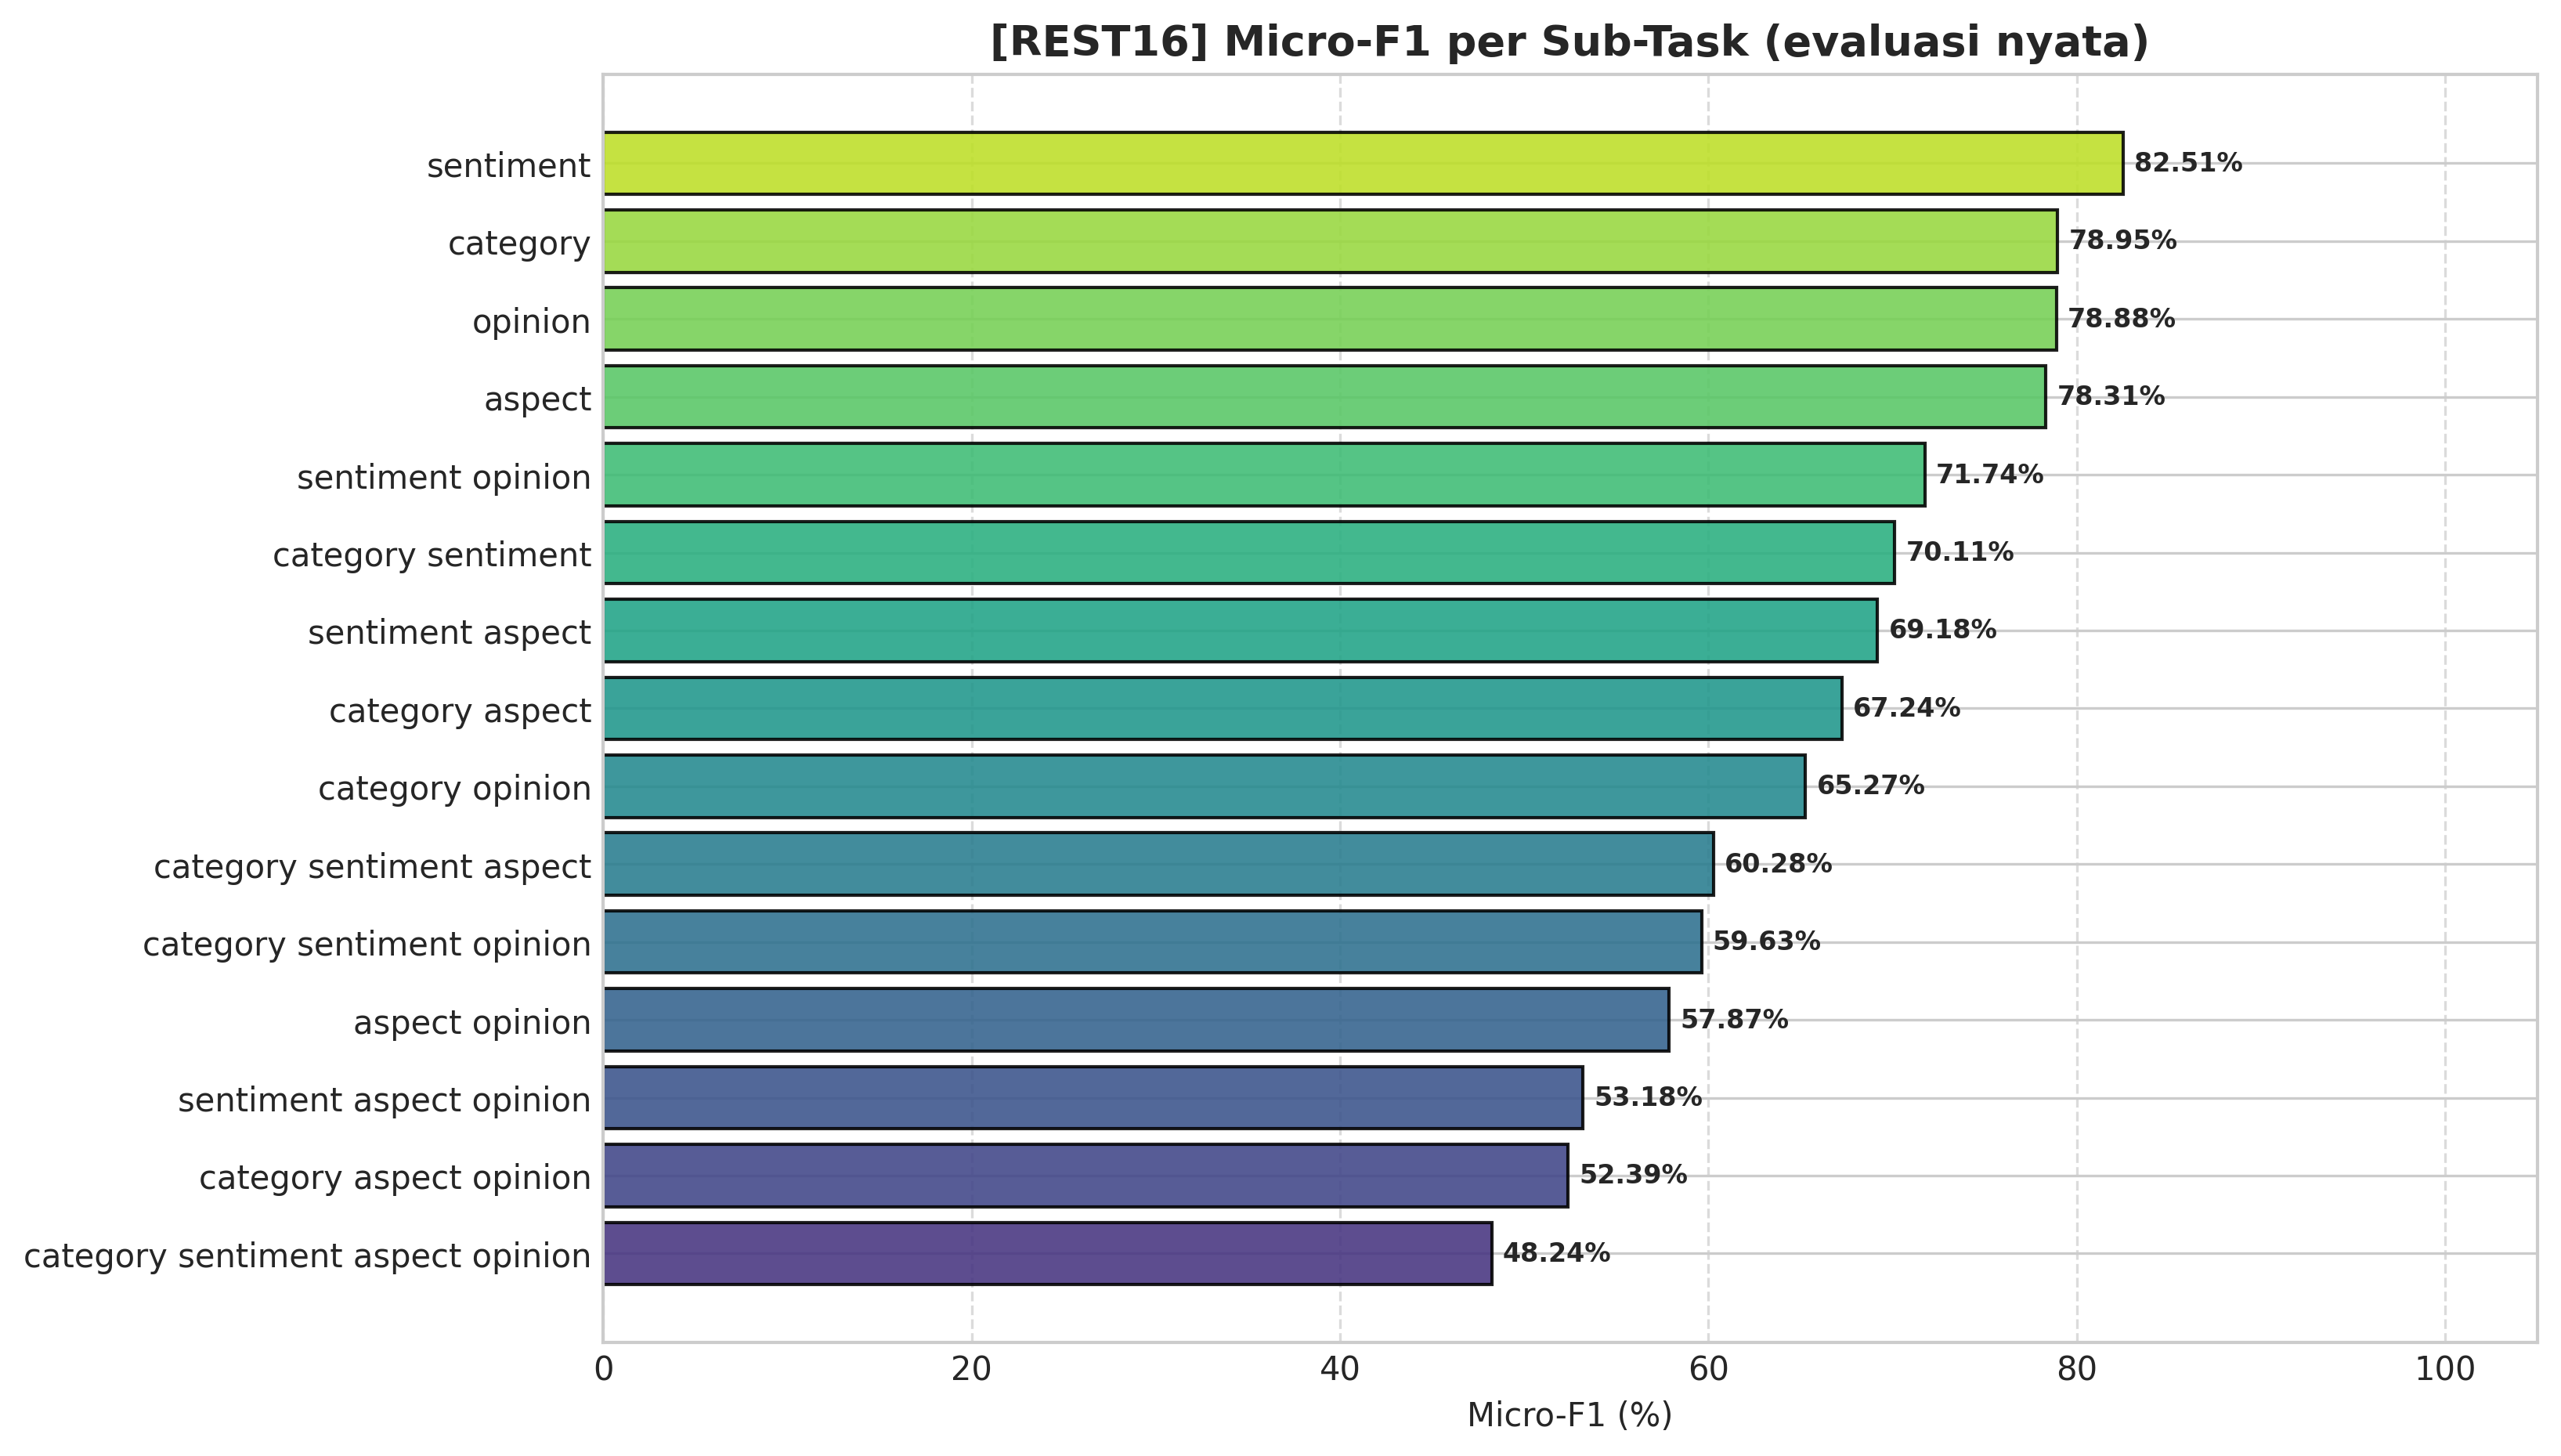

[plot] Disimpan: /content/ACOS/results/rest16_02092026_135007/plots/04b_step2_subtask_f1.png
[metrik] Metrik sub-task disimpan: /content/ACOS/results/rest16_02092026_135007/logs/subtask_metrics.json
[file] Prediksi lengkap: /content/ACOS/results/rest16_02092026_135007/logs/result.txt


In [6]:
print(f"Memuat checkpoint step 2 terbaik dari: {step2_checkpoint_dir}")
model = CategorySentiClassification.from_pretrained(step2_checkpoint_dir, num_labels=num_labels)
model.to(device)
model.eval()

class ArgsHelper:
    def __init__(self):
        self.output_dir = logs_dir
        self.max_seq_length = MAX_SEQ_LENGTH

eval_args = ArgsHelper()

import logging
logger = logging.getLogger("Step2_Final")

# pair_eval menghitung metrik 15 sub-task tetapi hanya menulisnya ke logger.
# SubtaskMetricCapture menangkap baris log itu supaya angkanya bisa ditabelkan.
with SubtaskMetricCapture(logger) as cap:
    final_res = pair_eval("best_checkpoint", eval_args, logger, tokenizer, model, eval_dataloader,
                          eval_gold, label_list, device, TASK_NAME, eval_type="test")

df_final = pd.DataFrame([{
    "Metrik": k, "Nilai": v, "Persen": round(v * 100, 2) if isinstance(v, float) else v,
} for k, v in final_res.items()])

rep.section("6. Hasil akhir quadruple pada test set")
export_step_table(df_final, name="step2_06_hasil_quadruple_final", csv_dir=csv_dir, md_dir=md_dir,
                  title=f"Hasil Akhir Ekstraksi Quadruple ({DOMAIN.upper()})",
                  notes=("Skor pipeline penuh hanya bila kandidat berasal dari prediksi step 1 "
                         f"(sumber saat ini: {'prediksi step 1' if pakai_1st else 'gold pair'})."))
rep.table(df_final, caption="Metrik quadruple")

print("\nHasil akhir quadruple pada test set:")
for k, v in final_res.items():
    print(f"  {k}: {v*100:.2f}%")

# Metrik per sub-task hasil tangkapan log
df_sub = cap.to_frame()
if df_sub.empty:
    print("\n[catatan] Metrik sub-task tidak tertangkap dari log pair_eval.")
    rep.section("7. Metrik per sub-task").text(
        "Metrik sub-task tidak tertangkap. Pastikan level logger memungkinkan pesan INFO."
    )
else:
    df_sub_pct = df_sub.copy()
    for c in ["Precision", "Recall", "Micro_F1"]:
        df_sub_pct[c] = (df_sub_pct[c] * 100).round(2)

    rep.section("7. Metrik per sub-task (15 kombinasi elemen)")
    export_step_table(df_sub_pct, name="step2_07_metrik_15_subtask", csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Metrik 15 Sub-Task Hasil Evaluasi Nyata ({DOMAIN.upper()})",
                      notes=("Diambil langsung dari keluaran pair_eval, bukan angka yang ditulis manual. "
                             "N_Elements = jumlah elemen quadruple yang dievaluasi bersamaan."),
                      max_rows_md=20)
    rep.table(df_sub_pct, max_rows=20, caption="Metrik per sub-task")

    p_sub = os.path.join(plots_dir, "04b_step2_subtask_f1.png")
    plot_subtask_metrics(df_sub, p_sub,
                         title=f"[{DOMAIN.upper()}] Micro-F1 per Sub-Task (evaluasi nyata)")
    rep.image(p_sub, "Micro-F1 per sub-task")

    # Simpan juga sebagai JSON agar notebook 05 bisa memakai angka nyata
    subtask_json = os.path.join(logs_dir, "subtask_metrics.json")
    with open(subtask_json, "w", encoding="utf-8") as jf:
        json.dump(cap.to_dict(), jf, indent=2)
    print(f"[metrik] Metrik sub-task disimpan: {subtask_json}")

result_file = os.path.join(logs_dir, "result.txt")
if os.path.exists(result_file):
    print(f"[file] Prediksi lengkap: {result_file}")
    rep.text(f"File prediksi lengkap: `{result_file}`")


## 7. Display Step 2 Training Loss & Metrics Curve

[plot] Kurva loss training & metrik quadruple


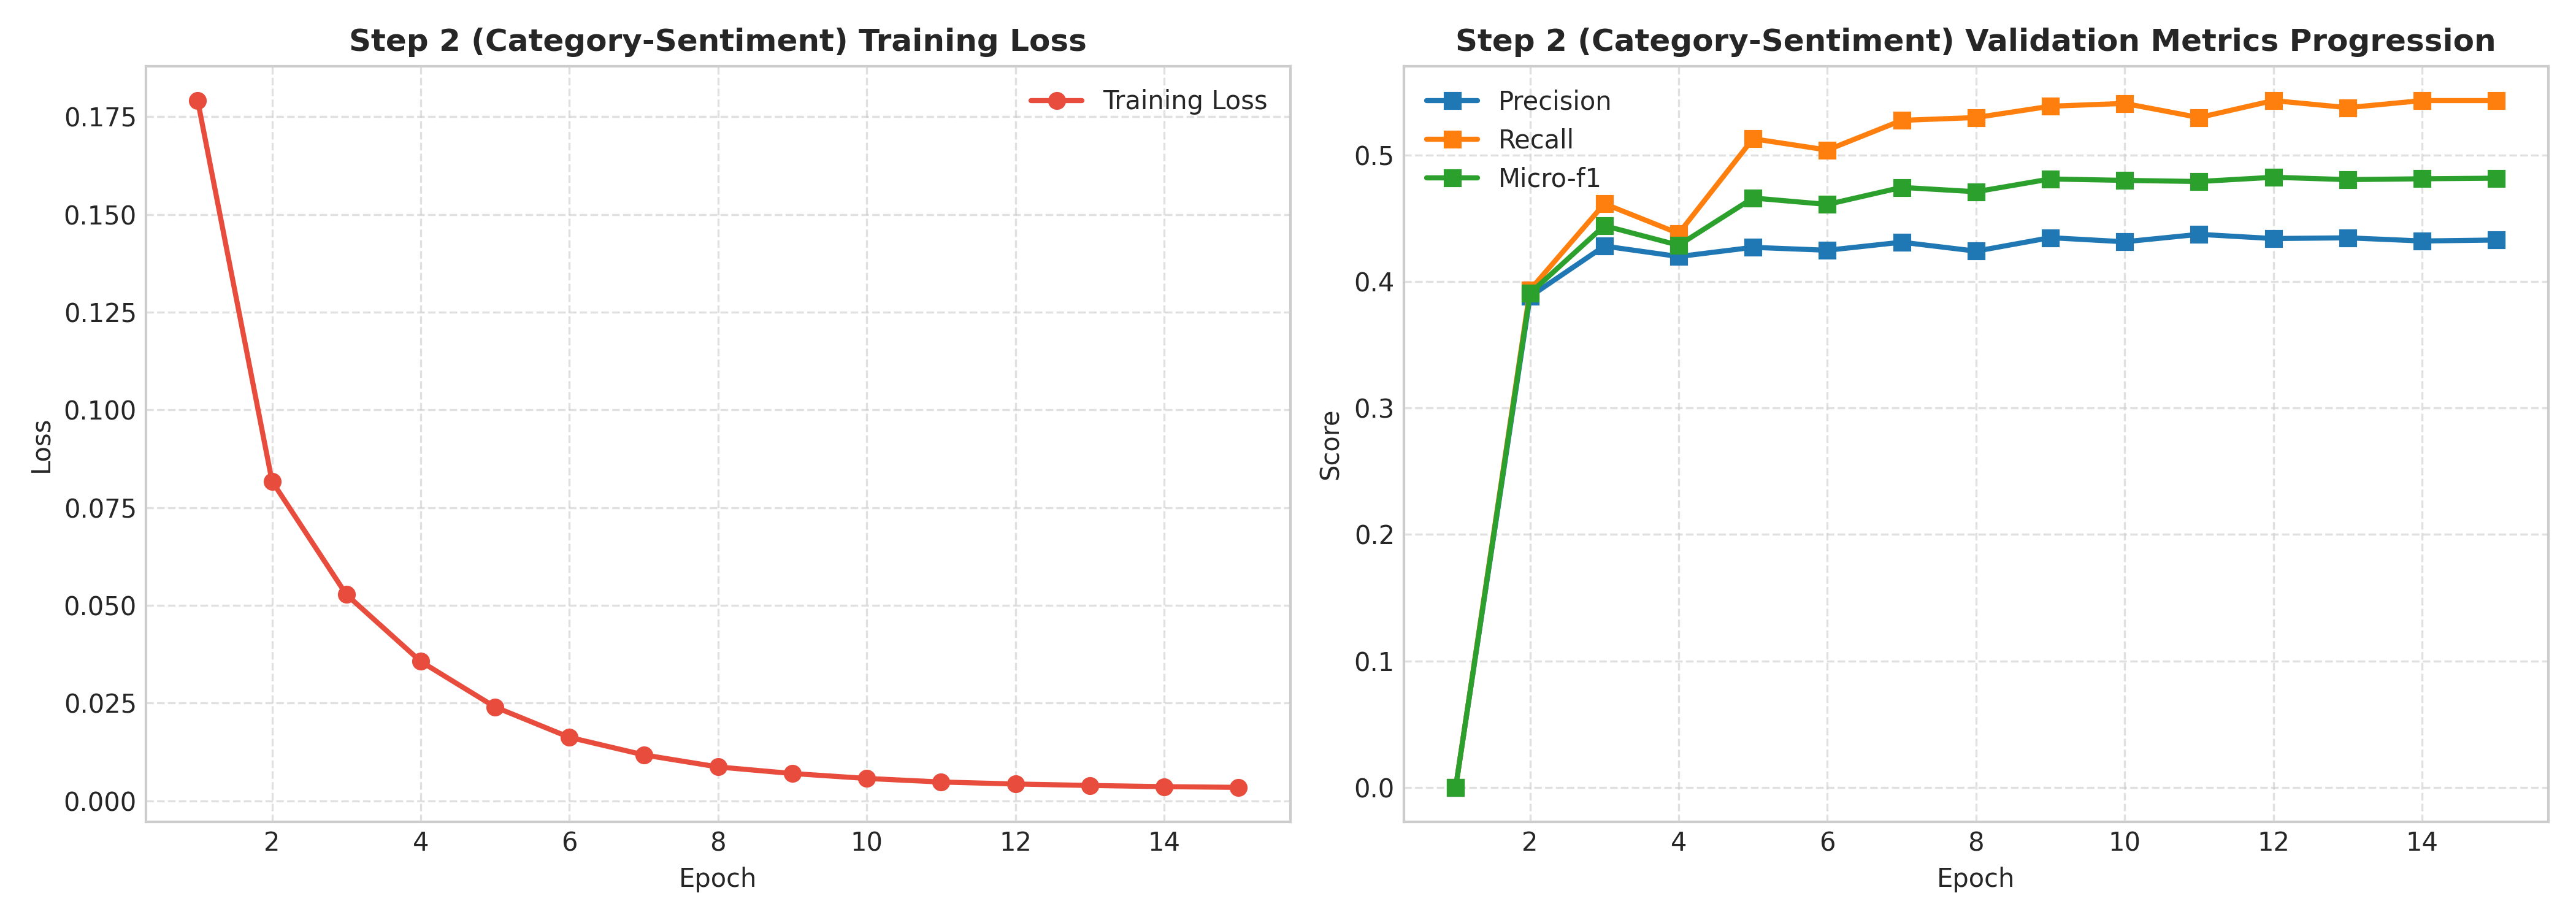

[plot] Micro-F1 per sub-task


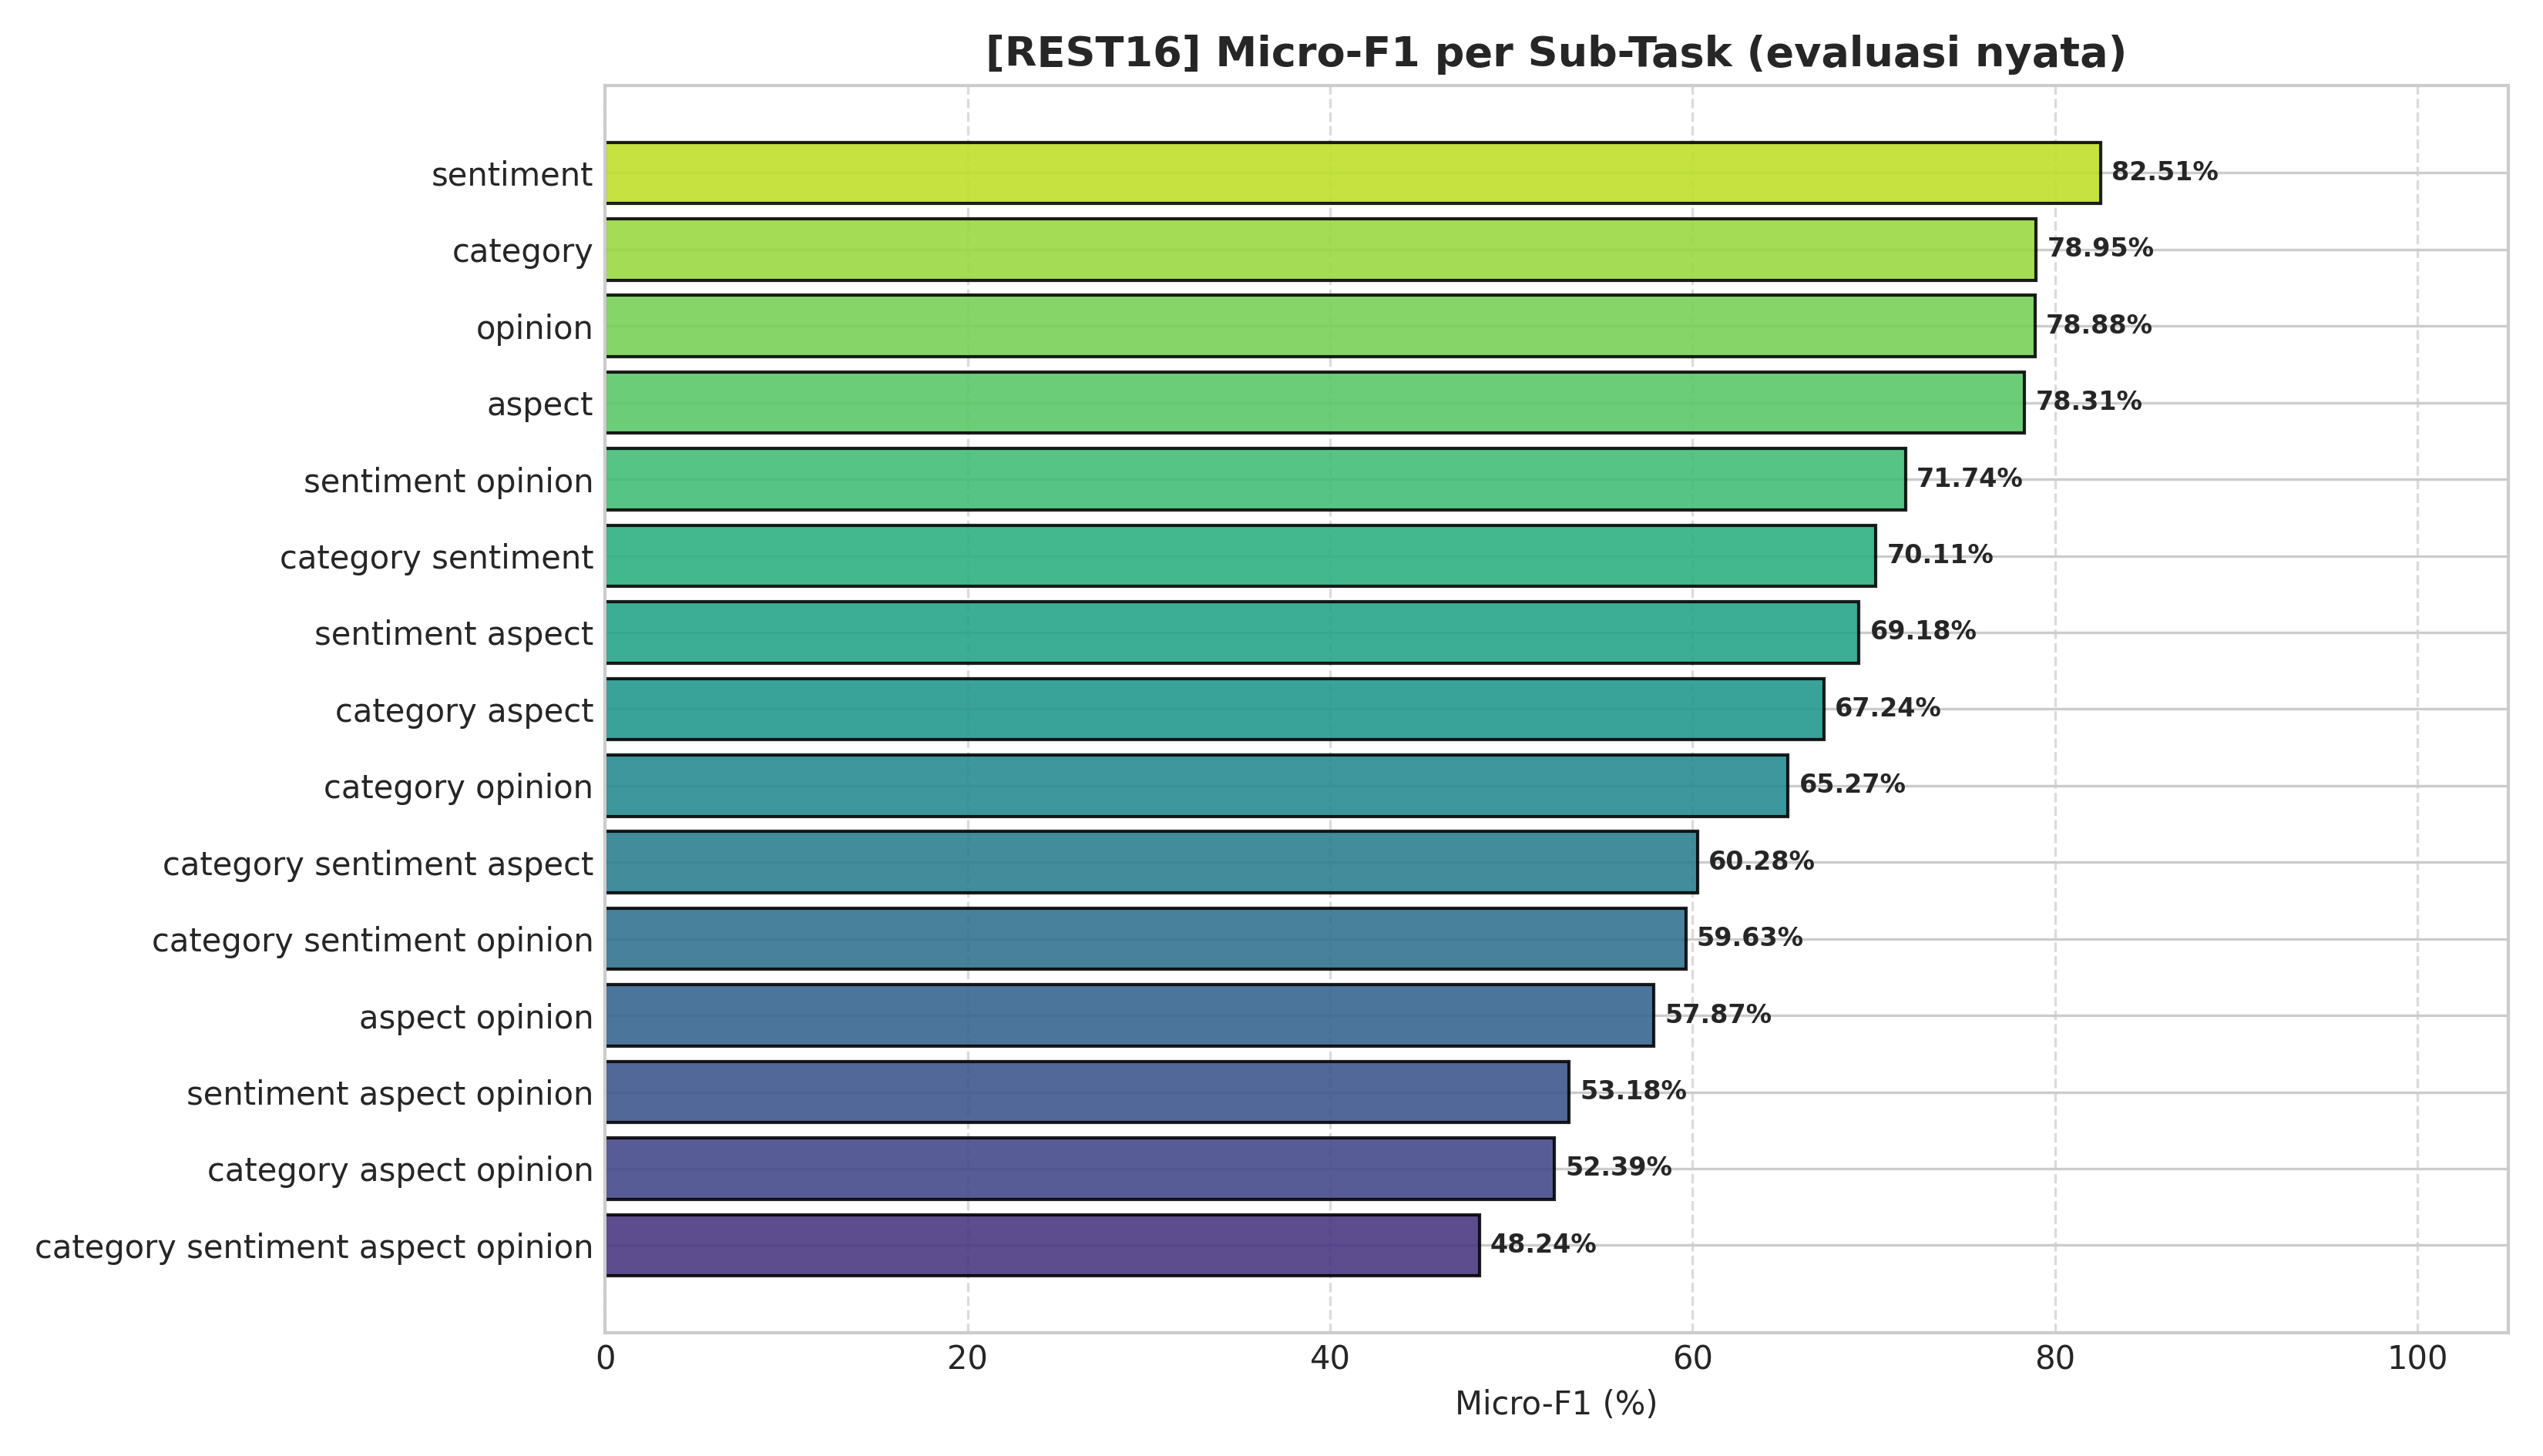

[markdown] Laporan disimpan: /content/ACOS/results/rest16_02092026_135007/md/04_step2_klasifikasi.md

Laporan Markdown step 2: /content/ACOS/results/rest16_02092026_135007/md/04_step2_klasifikasi.md
Lanjut ke '05_ACOS_Evaluation_and_Interactive_Inference.ipynb'.


In [7]:
from IPython.display import Image, display

step2_plots = [
    ("04_step2_training_loss_f1_curve.png", "Kurva loss training & metrik quadruple"),
    ("04b_step2_subtask_f1.png", "Micro-F1 per sub-task"),
]

rep.section("8. Visualisasi step 2")
for fname, caption in step2_plots:
    path = os.path.join(plots_dir, fname)
    if os.path.exists(path):
        print(f"[plot] {caption}")
        display(Image(path))
    else:
        print(f"[plot] Tidak ditemukan (dilewati): {fname}")

rep.text(f"Sesi: `{session_dirs['root']}`")
report_path = rep.save()

print(f"\nLaporan Markdown step 2: {report_path}")

# Sinkronisasi akhir memastikan notebook 04*.ipynb dan seluruh hasil tersimpan di /content/drive/MyDrive/ACOS
ensure_notebook_saved_to_drive()

print("\n" + "="*70)
print("🎉 RINGKASAN PERSISTENSI GOOGLE DRIVE (/content/drive/MyDrive/ACOS):")
if HAS_DRIVE:
    print(f"   ✅ Notebook 04  : /content/drive/MyDrive/ACOS/notebooks/04_ACOS_Step2_Category_Sentiment_Classification.ipynb")
    print(f"   ✅ Notebook 04  : /content/drive/MyDrive/ACOS/04_ACOS_Step2_Category_Sentiment_Classification.ipynb")
    print(f"   ✅ Checkpoint Sesi: {step2_checkpoint_dir}")
    print(f"   ✅ Checkpoint Glob: {global_step2_ckpt}")
    print(f"   ✅ Direktori Sesi: {session_dirs['root']}")
    print(f"   ✅ Laporan MD   : {report_path}")
    print("   💾 Semua model checkpoint, metrik CSV, grafik plot, dan laporan tersimpan aman di Google Drive.")
else:
    print("   💻 Berjalan di lingkungan lokal. Seluruh artifact tersimpan di base_project_dir.")
print("="*70)
print("Lanjut ke '05_ACOS_Evaluation_and_Interactive_Inference.ipynb'.")